<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/band_gap_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bandgap Preidction of Inorganic Material with Two-Stage Neural Network**

Replication paper using PyTorch, Matminer, and composition descriptor.

* Rio Agustian Gilang Fernandp
* Advanced Material Science and Nanotechnology

This notebook is based on this paper: https://doi.org/10.1021/acs.jpclett.8b00124

1. Problem
  Experimental dataset has a lot of zero value (metal) that make the regular regression model can be bias and inaccurate.
2. Solution
  Make architecture two-stage piple using PyTorch. The first stage is detect metal or non metal (classifier). The second stage is predict the bandgap energy (regression) only for non metal.
3. Feature engineering
  Change from molecule string to numerical vector with physical meaning using compositional descriptors (`Magpie` and `Matminer`).
4. Tech Stack
  * `Python`, `PyTorch`, `Scikit-learn`, `Matminer`, `Pandas`.


# **1. Setup and Data Loading**

Prepare for the environment and load the raw data.

## 1.1 Import libraries

In [ ]:
!pip install matminer

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from matminer.datasets import load_dataset
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error

## 1.2 Load dataset

In [ ]:
# Load dataset again to ensure a fresh start if the DataFrame was reset
from matminer.datasets import load_dataset
df = load_dataset('matbench_expt_gap')

# **2. Feature Engineering**

Convert the molecule text to numbers

## 2.1 Convert string in column 'composition' to a Pymatgen object composition

In [ ]:
from matminer.featurizers.conversions import StrToComposition

# convert string to object composition and store it in a new column
df = StrToComposition(target_col_id='composition_object').featurize_dataframe(df, "composition")

StrToComposition:   0%|          | 0/4604 [00:00<?, ?it/s]

In [ ]:
df.head()

,composition,gap expt,composition_object
0,Ag(AuS)2,0.00,"(Ag, Au, S)"
1,Ag(W3Br7)2,0.00,"(Ag, W, Br)"
2,Ag0.5Ge1Pb1.75S4,1.83,"(Ag, Ge, Pb, S)"
3,Ag0.5Ge1Pb1.75Se4,1.51,"(Ag, Ge, Pb, Se)"
4,Ag2BBr,0.00,"(Ag, B, Br)"


## 2.2 Use Magpie Descriptors (use `ElementProperty` from `Matminer`) to have the statistics of the element (mass, electronegativity, radius, etc)

In [ ]:
from matminer.featurizers.composition import ElementProperty

# generate features
ep_feat = ElementProperty.from_preset(preset_name="magpie")
df = ep_feat.featurize_dataframe(df, col_id="composition_object")
df.head()

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/4604 [00:00<?, ?it/s]

,composition,gap expt,composition_object,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Ag(AuS)2,0.00,"(Ag, Au, S)",16.0,79.0,63.0,47.400000,25.280000,16.0,65.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,163.000000,74.400000,70.0
1,Ag(W3Br7)2,0.00,"(Ag, W, Br)",35.0,74.0,39.0,46.714286,15.619048,35.0,51.0,...,0.0,0.0,0.0,0.0,64.0,229.0,165.0,118.809524,73.079365,64.0
2,Ag0.5Ge1Pb1.75S4,1.83,"(Ag, Ge, Pb, S)",16.0,82.0,66.0,36.275862,23.552913,16.0,65.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,139.482759,76.670630,70.0
3,Ag0.5Ge1Pb1.75Se4,1.51,"(Ag, Ge, Pb, Se)",32.0,82.0,50.0,46.206897,17.388823,34.0,65.0,...,0.0,0.0,0.0,0.0,14.0,225.0,211.0,108.586207,104.370987,14.0
4,Ag2BBr,0.00,"(Ag, B, Br)",5.0,47.0,42.0,33.500000,14.250000,47.0,65.0,...,0.0,0.0,0.0,0.0,64.0,225.0,161.0,170.000000,55.000000,225.0


## 2.3 Clean the data (drop the non numerical data column)

In [ ]:
# delete non feature colomn (:composition and gap expt)
features_columns = [col for col in df.columns if col not in ["composition", "gap expt", "composition_object"]]
X = df[features_columns].values
y = df["gap expt"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (4604, 132)
y shape: (4604,)


# **3. Preprocessing and Data Splitting**

Prepare the data to be ready for Neural Network input.

## 3.1 Train-test Split (80 % training and 20 % testing)

In [ ]:
# preprocessing
from sklearn.model_selection import train_test_split

# train test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=67)

## 3.2 Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler

# normalize (important for convergence PyTorch Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

## 3.2 Convert to Tensor

In [ ]:
import torch

# convert to PyTorch Tensor
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).view(-1, 1)
X_test  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test  = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

# **4. Model Architecture**

Design the neural network

In [ ]:
import torch.nn as nn

# neural network (MLP)
class MLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.Linear(64, 32),
        nn.Linear(32, 1),
        nn.ReLU()
    )
  def forward(self, x):
    return self.layer_stack(x)

# **5. Stage 1 Training: Classification**

## 5.1 Labelling

Make a binary label

```
if bandgap < 0.001:
  is_metal, label is 0
else:
  non_metal, label is 1
```

In [ ]:
# make label, 1 if non-metal and 0 if metal
y_train_class = (y_train_raw > 0.001).astype(float)
y_train_class_tensor = torch.FloatTensor(y_train_class).view(-1, 1)

## 5.2 Initiation, Loss Function, Optimizer

In [ ]:
import torch.optim as optim

# classifier model (motal or non metal)
input_dim = X_train.shape[1]
model_clf = MLP(input_dim)
loss_clf = nn.BCEWithLogitsLoss()
optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.001)

## 5.3. Training Loop

In [ ]:
# training loop classifier
epochs = 5000
for epoch in range(epochs):
  model_clf.train()
  optimizer_clf.zero_grad()

  outputs = model_clf(X_train)
  loss = loss_clf(outputs, y_train_class_tensor)

  loss.backward()
  optimizer_clf.step()

  if (epoch+1) % 1000 == 0:
    print(f"Epoch: {epoch+1} | Loss classifier: {loss.item():.4f}")

Epoch: 1000 | Loss classifier: 0.4971
Epoch: 2000 | Loss classifier: 0.4974
Epoch: 3000 | Loss classifier: 0.4973
Epoch: 4000 | Loss classifier: 0.4971
Epoch: 5000 | Loss classifier: 0.4977


## 5.4 Early Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

# valifation classifier
model_clf.eval()
with torch.inference_mode():
  logits = model_clf(X_test)
  preds_prob = torch.sigmoid(logits)
  pred_class = (preds_prob > 0.5).float()

  # real label
  y_test_class = (y_test_raw > 0.001).astype(float)
  acc = accuracy_score(y_test_class, pred_class.numpy())
  print(f"Accuracy detection metal/non-metal: {acc:.3f}")

Accuracy detection metal/non-metal: 0.868


# **6. Stage 2 Training: Regression (Band Gap Predictor)**

Train the model to predict the band gap

## 6.1 Filtering

Only take trainin data that is non metal

In [ ]:
# regresor for non metal
mask_non_metal = (y_train_raw > 0.001)
X_train_nm = X_train_scaled[mask_non_metal]
y_train_nm = y_train_raw[mask_non_metal]

# to tensor
X_train_nm = torch.FloatTensor(X_train_nm)
y_train_nm = torch.FloatTensor(y_train_nm).view(-1, 1)

## 6.2 Initiation  Model, Loss FUnction, and Optimizer

In [ ]:
# make model
model_reg = MLP(input_dim)
loss_reg = nn.MSELoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001)

## 6.3 Training Loop

In [ ]:
# training loop regressor
epochs = 5000
for epoch in range(epochs):
  model_reg.train()
  optimizer_reg.zero_grad()

  outputs = model_reg(X_train_nm)
  loss = loss_reg(outputs, y_train_nm)

  loss.backward()
  optimizer_reg.step()

  if (epoch+1) % 1000 == 0:
    print(f"Epoch: {epoch+1} | Loss regressor (MSE): {loss.item():.4f}")

Epoch: 1000 | Loss regressor (MSE): 0.5244
Epoch: 2000 | Loss regressor (MSE): 0.5220
Epoch: 3000 | Loss regressor (MSE): 0.5214
Epoch: 4000 | Loss regressor (MSE): 0.5215
Epoch: 5000 | Loss regressor (MSE): 0.5212


# **7. Pipeline and Combined Evaluation**

Combined two model into one single function

## 7.1 Make the Prediction Function

In [ ]:
# combine both of them
def predict_pipeline(X_tensor):
  model_clf.eval()
  model_reg.eval()

  with torch.inference_mode():
    # classification metal ot non metal
    logits = model_clf(X_tensor)
    probs = torch.sigmoid(logits)

    # if probability > 0.5, is metal, else non metal
    is_non_metal = (probs > 0.5).float()

    # regression for ALL material
    gap_preds = model_reg(X_tensor)

    # filer the result. Zero if metal
    final_preds = gap_preds * is_non_metal

  return final_preds

## 7.2 Calculate the Test Data Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# test set predictions
final_predictions = predict_pipeline(X_test)

# error
mae = mean_absolute_error(y_test_raw, final_predictions.numpy())
print(f"Final MAE: {mae:.4f}")

Final MAE: 0.4829


In [ ]:
mse = mean_squared_error(y_test, final_predictions)
mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mse)

print("---Results---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

print("\nExample predicitions vs real")
for i in range(5):

  print(f"Prediction: {final_predictions[i].item():.2f} eV | Real: {y_test[i].item():.2f}")

---Results---
MAE: 0.4829
RMSE: 1.1509

Example predicitions vs real
Prediction: 1.56 eV | Real: 1.93
Prediction: 0.00 eV | Real: 0.00
Prediction: 0.59 eV | Real: 0.28
Prediction: 2.09 eV | Real: 2.20
Prediction: 2.21 eV | Real: 1.89


# **8. Inference (User Input)**

## 8.1 The `bandgap()` Function

In [ ]:
import pandas as pd

def bandgap(molecule):
  # single DataFrame that compatible with Matminer
  df_new = pd.DataFrame({"composition": [molecule]})

  # string to composition
  df_new = StrToComposition(target_col_id='composition_object').featurize_dataframe(df_new, "composition")

  # featurization
  ep_feat = ElementProperty.from_preset(preset_name="magpie")
  df_new = ep_feat.featurize_dataframe(df_new, col_id="composition_object")

  # drop non useful input
  input_freature = df_new.drop(columns=["composition", "composition_object"]).values

  # scaling / normalization
  input_scaled = scaler.transform(input_freature)
  input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
  result = predict_pipeline(input_tensor)

  return print(f"\nMaterial: {molecule} \nPredicted bandgap: {result.item():.3f} eV")

## 8.2 User Input

In [ ]:
bandgap("GaN")

StrToComposition:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/1 [00:00<?, ?it/s]


Material: GaN 
Predicted bandgap: 0.000 eV


## 8.3 Prediction vs Real Bandgap

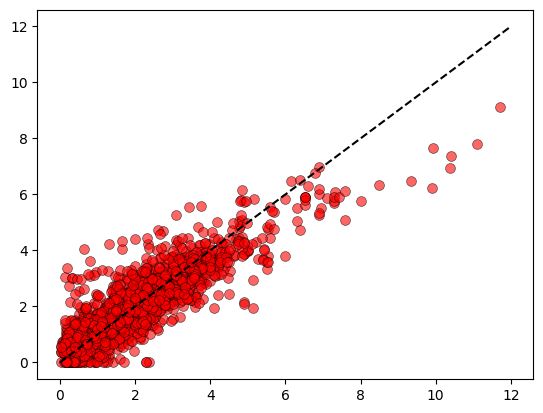

In [ ]:
# regresor for non metal
mask_non_metal = (y_test_raw > 0.001)
X_test_nm = X_test_scaled[mask_non_metal]
y_test_nm = y_test_raw[mask_non_metal]

# to tensor
X_test_nm = torch.FloatTensor(X_train_nm)
y_test_nm = torch.FloatTensor(y_train_nm).view(-1, 1)

model_reg.eval()
with torch.inference_mode():
  predictions = model_reg(X_test_nm)

plt.plot(np.arange(0, 12, 0.001), np.arange(0, 12, 0.001), ls="--", c="k")
plt.scatter(y_test_nm, predictions,c='red',      # Warna Biru Matplotlib standar
           alpha=0.6,        # Transparansi (0.0 - 1.0) agar tumpukan terlihat
           edgecolor='k',    # Garis pinggir titik (hitam) agar tajam
           linewidth=0.5,    # Ketebalan garis pinggir
           s=50,             # Ukuran titik
           label='Non-Metals');